# EXAMEN — Modelación Ambiental
Resolución de los ejercicios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from IPython.display import display, Markdown
from pathlib import Path

OUT = Path("examen_resultados"); OUT.mkdir(exist_ok=True)
COL = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
plt.rcParams.update({
    "figure.figsize": (8.2, 4.4), "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#dcdbd6", "grid.linewidth": 0.8, "axes.edgecolor": "#dcdbd6",
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlesize": 11,
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "legend.frameon": False, "lines.linewidth": 2, "axes.prop_cycle": plt.cycler(color=COL),
})
def eq(s): display(Markdown(f"$${s}$$"))

---
# EJERCICIO 1 — Dispersión de molibdeno en el río Chili

**Datos:** M = 100 kg/día · u = 100 m/día · D = 0.1 m²/día · k = 0.1 día⁻¹ · t = 1 día
**Tramos:** 100 m, 500 m y 1 km · **ECA A1 (molibdeno) = 0.07 mg/L** (A2 y A3 no establecen valor)

## 1. Modelo
Descarga puntual con advección, difusión y degradación de primer orden:

$$C(x,t) = \frac{M}{\sqrt{4\pi D t}}\;\exp\left(-\frac{(x-ut)^2}{4Dt}\right)\;e^{-kt}$$

In [2]:
# ===== DATOS =====
M, u, D, k, t = 100.0, 100.0, 0.1, 0.1, 1.0      # kg/día, m/día, m²/día, 1/día, día
ECA = 0.07                                        # mg/L
tramos = [100.0, 500.0, 1000.0]

# ===== 2. TÉRMINOS COMUNES (iguales para los tres tramos) =====
raiz  = np.sqrt(4*np.pi*D*t)
pref  = M/raiz
e_deg = np.exp(-k*t)
x_centro = u*t

display(Markdown("**2. Términos comunes**"))
eq(rf"\sqrt{{4\pi D t}} = \sqrt{{4\pi({D})({t:g})}} = \sqrt{{{4*np.pi*D*t:.4f}}} = {raiz:.4f}")
eq(rf"\frac{{M}}{{\sqrt{{4\pi D t}}}} = \frac{{{M:g}}}{{{raiz:.4f}}} = {pref:.2f}")
eq(rf"e^{{-kt}} = e^{{-({k})({t:g})}} = {e_deg:.4f}")
eq(rf"x_{{centro}} = u\,t = ({u:g})({t:g}) = {x_centro:g}\ \text{{m}}")

**2. Términos comunes**

$$\sqrt{4\pi D t} = \sqrt{4\pi(0.1)(1)} = \sqrt{1.2566} = 1.1210$$

$$\frac{M}{\sqrt{4\pi D t}} = \frac{100}{1.1210} = 89.21$$

$$e^{-kt} = e^{-(0.1)(1)} = 0.9048$$

$$x_{centro} = u\,t = (100)(1) = 100\ \text{m}$$

## 3. Reemplazo para cada tramo

In [3]:
def resolver_tramo(x):
    num, den = (x - u*t)**2, 4*D*t
    gauss = np.exp(-num/den)
    C = pref*gauss*e_deg
    display(Markdown(f"**Tramo x = {x:g} m**"))
    eq(rf"C({x:g},{t:g}) = \frac{{{M:g}}}{{\sqrt{{4\pi({D})({t:g})}}}}"
       rf"\exp\left(-\frac{{({x:g}-{u:g}\cdot{t:g})^2}}{{4({D})({t:g})}}\right)e^{{-({k})({t:g})}}")
    eq(rf"C = {pref:.2f}\times\exp\left(-\frac{{({x-u*t:,.0f})^2}}{{{den:g}}}\right)\times{e_deg:.4f}"
       rf" = {pref:.2f}\times {gauss:.4g}\times{e_deg:.4f}")
    eq(rf"\boxed{{C({x:g}\ \text{{m}}) = {C:,.2f}\ \text{{mg/L}}}}" if C > 0.01 else
       rf"\boxed{{C({x:g}\ \text{{m}}) \approx 0\ \text{{mg/L}}}}")
    return C

C_tramos = [resolver_tramo(x) for x in tramos]

**Tramo x = 100 m**

$$C(100,1) = \frac{100}{\sqrt{4\pi(0.1)(1)}}\exp\left(-\frac{(100-100\cdot1)^2}{4(0.1)(1)}\right)e^{-(0.1)(1)}$$

$$C = 89.21\times\exp\left(-\frac{(0)^2}{0.4}\right)\times0.9048 = 89.21\times 1\times0.9048$$

$$\boxed{C(100\ \text{m}) = 80.72\ \text{mg/L}}$$

**Tramo x = 500 m**

...

$$\boxed{C(500\ \text{m}) \approx 0\ \text{mg/L}}$$

**Tramo x = 1000 m**

$$C(1000,1) = \frac{100}{\sqrt{4\pi(0.1)(1)}}\exp\left(-\frac{(1000-100\cdot1)^2}{4(0.1)(1)}\right)e^{-(0.1)(1)}$$

$$C = 89.21\times\exp\left(-\frac{(900)^2}{0.4}\right)\times0.9048 = 89.21\times 0\times0.9048$$

$$\boxed{C(1000\ \text{m}) \approx 0\ \text{mg/L}}$$

## 4. Comparación con el ECA

In [4]:
tab1 = pd.DataFrame({
    "Tramo (m)": tramos,
    "C a t = 1 día (mg/L)": C_tramos,
    "ECA A1 (mg/L)": ECA,
    "C / ECA": [c/ECA for c in C_tramos],
    "Veredicto": ["NO CUMPLE" if c > ECA else "Cumple (a este tiempo)" for c in C_tramos],
})
display(tab1)

# Franja del río que supera el ECA a t = 1 día
semi = np.sqrt(4*D*t*np.log(pref*e_deg/ECA))
print(f"Franja que supera el ECA: de {x_centro-semi:.2f} m a {x_centro+semi:.2f} m "
      f"(ancho = {2*semi:.2f} m)")
print(f"Ancho característico de la nube: sigma = sqrt(2·D·t) = {np.sqrt(2*D*t):.2f} m")
print(f"Llegada de la nube a cada tramo (t = x/u): " + " | ".join(f"{x:g} m -> {x/u:g} d" for x in tramos))

,Tramo (m),C a t = 1 día (mg/L),ECA A1 (mg/L),C / ECA,Veredicto
0,100.0,80.717113,0.07,1153.101613,NO CUMPLE
1,500.0,0.000000,0.07,0.000000,Cumple (a este tiempo)
2,1000.0,0.000000,0.07,0.000000,Cumple (a este tiempo)


Franja que supera el ECA: de 98.32 m a 101.68 m (ancho = 3.36 m)
Ancho característico de la nube: sigma = sqrt(2·D·t) = 0.45 m
Llegada de la nube a cada tramo (t = x/u): 100 m -> 1 d | 500 m -> 5 d | 1000 m -> 10 d


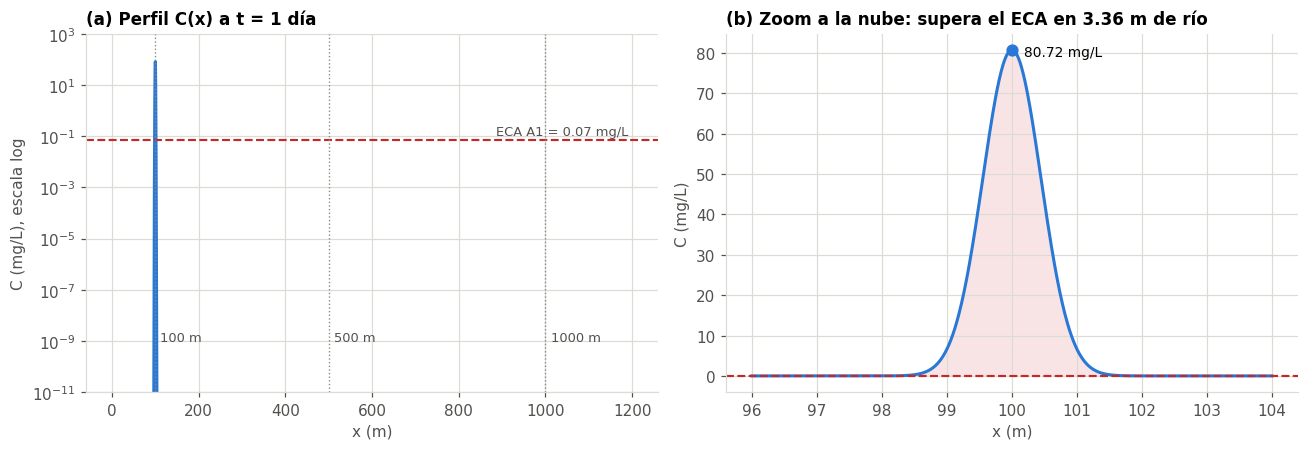

In [5]:
# ===== 5. GRÁFICAS =====
C_x = lambda x, tt: M/np.sqrt(4*np.pi*D*tt)*np.exp(-(x - u*tt)**2/(4*D*tt))*np.exp(-k*tt)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

xg = np.linspace(0.1, 1200, 4000)
ax[0].semilogy(xg, np.maximum(C_x(xg, t), 1e-12), color=COL[0])
ax[0].axhline(ECA, color="#c62828", ls="--", lw=1.4)
ax[0].text(1190, ECA*1.6, "ECA A1 = 0.07 mg/L", ha="right", fontsize=8.5, color="#52514e")
for x_ in tramos:
    ax[0].axvline(x_, color="#8a8981", ls=":", lw=0.9)
    ax[0].text(x_ + 12, 1e-9, f"{x_:g} m", fontsize=8.5, color="#52514e")
ax[0].set_ylim(1e-11, 1e3); ax[0].set_xlabel("x (m)"); ax[0].set_ylabel("C (mg/L), escala log")
ax[0].set_title("(a) Perfil C(x) a t = 1 día")

xz = np.linspace(x_centro - 4, x_centro + 4, 800)
cz = C_x(xz, t)
ax[1].plot(xz, cz, color=COL[0])
ax[1].axhline(ECA, color="#c62828", ls="--", lw=1.4)
ax[1].fill_between(xz, ECA, cz, where=(cz > ECA), color="#c62828", alpha=0.12, lw=0)
ax[1].plot([x_centro], [max(C_tramos)], "o", color=COL[0], ms=7)
ax[1].annotate(f"{max(C_tramos):.2f} mg/L", (x_centro, max(C_tramos)), xytext=(8, -4),
               textcoords="offset points", fontsize=9)
ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("C (mg/L)")
ax[1].set_title(f"(b) Zoom a la nube: supera el ECA en {2*semi:.2f} m de río")
fig.tight_layout(); fig.savefig(OUT/"ej1.png"); plt.show()

## 6. Análisis

**Por qué la concentración es máxima en 100 m.** La advección transporta el centro de la nube a la
velocidad del río, y a t = 1 día ese centro está exactamente en x = u·t = 100 m. Ahí el término
gaussiano vale 1 (exponente cero) y solo actúan dos reducciones: la **difusión**, que repartió la masa
en un ancho de √(4Dt) ≈ 0.63 m, y la **degradación**, que eliminó 1 − e^(−0.1) ≈ 9.5 % de la masa en el
primer día. Por eso el valor baja de 89.21 a **80.72 mg/L**.

**Por qué da ≈ 0 en 500 m y 1 km.** No es porque el río esté limpio, sino porque **la nube todavía no
llega**: viaja a 100 m/día y, como el coeficiente de difusión es muy pequeño (D = 0.1 m²/día), la nube
es muy angosta y casi no se adelanta a la corriente. El exponente gaussiano se vuelve enorme y negativo
(e^−400 000 y e^−2 025 000) y anula la concentración. De hecho, la franja de río que supera el ECA mide
apenas ≈ 3.4 m (de 98.3 m a 101.7 m).

## 7. Conclusión

A t = 1 día el molibdeno **supera la Categoría A1 únicamente en el tramo de 100 m**, y de forma crítica:
80.72 mg/L frente al límite de 0.07 mg/L (≈ 1153 veces). Como para el molibdeno no existen valores en A2
ni A3, el agua de ese tramo **no puede clasificarse como potabilizable en ninguna categoría**. Los tramos
de 500 m y 1 km cumplen el ECA en ese instante, pero es **transitorio**: la nube llegará a 500 m a los
5 días y a 1 km a los 10 días. Por lo tanto, la captación de la PTAP no debe ubicarse cerca de la
descarga, el monitoreo debe seguir el avance de la nube en el tiempo y la medida de mitigación más
efectiva es **reducir la carga M en la fuente**, ya que la concentración pico es directamente
proporcional a ella.

---
# EJERCICIO 2 — Decaimiento del contaminante con la distancia

**Datos:** velocidad del río u = 1 m/s · contaminación **constante** (estado estacionario)

| Punto de muestra (km) | Concentración (mg/L) |
|---|---|
| 0.1 | 29 |
| 0.5 | 5 |
| 1.0 | 1 |

## 1. Modelo
Descarga constante: en estado estacionario el contaminante es arrastrado por advección mientras se
degrada con cinética de primer orden, de modo que la concentración decae exponencialmente con la
distancia:

$$C(x) = C_0\,e^{-k\,x/u} = C_0\,e^{-\beta x},\qquad \beta = \frac{k}{u}$$

Linealizando para ajustar los datos por mínimos cuadrados:

$$\ln C = \ln C_0 - \beta\,x$$

In [6]:
# ===== DATOS =====
x_km = np.array([0.1, 0.5, 1.0])          # km
C_m  = np.array([29.0, 5.0, 1.0])         # mg/L
x_m  = x_km*1000                          # m
u2   = 1.0                                # m/s
lnC  = np.log(C_m)

# ===== 2. REGRESIÓN LINEAL DE ln C CONTRA x =====
n   = len(x_m)
Sx, Sy   = x_m.sum(), lnC.sum()
Sxy, Sxx = (x_m*lnC).sum(), (x_m**2).sum()
b_pend = (n*Sxy - Sx*Sy)/(n*Sxx - Sx**2)      # pendiente = -beta
a_int  = lnC.mean() - b_pend*x_m.mean()       # intercepto = ln C0
beta   = -b_pend
C0     = np.exp(a_int)
k2     = beta*u2                              # 1/s
R2     = 1 - np.sum((lnC - (a_int + b_pend*x_m))**2)/np.sum((lnC - lnC.mean())**2)

display(Markdown("**2. Ajuste de los datos**"))
display(pd.DataFrame({"x (km)": x_km, "x (m)": x_m, "C (mg/L)": C_m, "ln C": lnC}))
eq(rf"\beta = -\frac{{n\sum xy-\sum x\sum y}}{{n\sum x^2-(\sum x)^2}}"
   rf" = -\frac{{{n}({Sxy:,.2f})-({Sx:,.0f})({Sy:.4f})}}{{{n}({Sxx:,.0f})-({Sx:,.0f})^2}} = {beta:.6f}\ \text{{m}}^{{-1}}")
eq(rf"\ln C_0 = \bar{{y}} - b\,\bar{{x}} = {lnC.mean():.4f} - ({b_pend:.6f})({x_m.mean():.2f}) = {a_int:.4f}"
   rf"\quad\Rightarrow\quad C_0 = e^{{{a_int:.4f}}} = {C0:.2f}\ \text{{mg/L}}")
eq(rf"k = \beta\,u = ({beta:.6f})({u2:g}) = {k2:.6f}\ \text{{s}}^{{-1}} = {k2*86400:.1f}\ \text{{día}}^{{-1}}")
eq(rf"R^2 = {R2:.4f}")
display(Markdown("**Modelo ajustado:**"))
eq(rf"\boxed{{C(x) = {C0:.2f}\,e^{{-{beta:.6f}\,x}}}}\quad (x\ \text{{en metros}})")

**2. Ajuste de los datos**

,x (km),x (m),C (mg/L),ln C
0,0.1,100.0,29.0,3.367296
1,0.5,500.0,5.0,1.609438
2,1.0,1000.0,1.0,0.000000


$$\beta = -\frac{n\sum xy-\sum x\sum y}{n\sum x^2-(\sum x)^2} = -\frac{3(1,141.45)-(1,600)(4.9767)}{3(1,260,000)-(1,600)^2} = 0.003720\ \text{m}^{-1}$$

$$\ln C_0 = \bar{y} - b\,\bar{x} = 1.6589 - (-0.003720)(533.33) = 3.6429\quad\Rightarrow\quad C_0 = e^{3.6429} = 38.20\ \text{mg/L}$$

$$k = \beta\,u = (0.003720)(1) = 0.003720\ \text{s}^{-1} = 321.4\ \text{día}^{-1}$$

$$R^2 = 0.9920$$

**Modelo ajustado:**

$$\boxed{C(x) = 38.20\,e^{-0.003720\,x}}\quad (x\ \text{en metros})$$

## 3. Verificación y predicción en otros puntos

In [7]:
C_pred = lambda x: C0*np.exp(-beta*x)
tab2 = pd.DataFrame({"x (km)": x_km, "C medida (mg/L)": C_m, "C modelo (mg/L)": C_pred(x_m)})
tab2["Error (%)"] = 100*(tab2["C modelo (mg/L)"] - tab2["C medida (mg/L)"])/tab2["C medida (mg/L)"]
display(tab2)

x_new = np.array([0, 250, 750, 1500, 2000.0])
tab2b = pd.DataFrame({"x (m)": x_new, "Tiempo de viaje t = x/u (min)": x_new/u2/60,
                      "C estimada (mg/L)": C_pred(x_new)})
display(tab2b)

t_medio = np.log(2)/k2
print(f"Vida media del contaminante: t½ = ln2/k = {t_medio:.1f} s = {t_medio/60:.2f} min")
print(f"Distancia en que la concentración se reduce a la mitad: x½ = ln2/beta = {np.log(2)/beta:.1f} m")
for objetivo in (1.0, 0.1):
    print(f"Distancia para llegar a {objetivo:g} mg/L: x = ln(C0/C)/beta = {np.log(C0/objetivo)/beta:,.0f} m")

,x (km),C medida (mg/L),C modelo (mg/L),Error (%)
0,0.1,29.0,26.335592,-9.187615
1,0.5,5.0,5.947149,18.942989
2,1.0,1.0,0.925798,-7.420236


,x (m),Tiempo de viaje t = x/u (min),C estimada (mg/L)
0,0.0,0.000000,38.203367
1,250.0,4.166667,15.073193
2,750.0,12.500000,2.346456
3,1500.0,25.000000,0.144120
4,2000.0,33.333333,0.022435


Vida media del contaminante: t½ = ln2/k = 186.3 s = 3.11 min
Distancia en que la concentración se reduce a la mitad: x½ = ln2/beta = 186.3 m
Distancia para llegar a 1 mg/L: x = ln(C0/C)/beta = 979 m
Distancia para llegar a 0.1 mg/L: x = ln(C0/C)/beta = 1,598 m


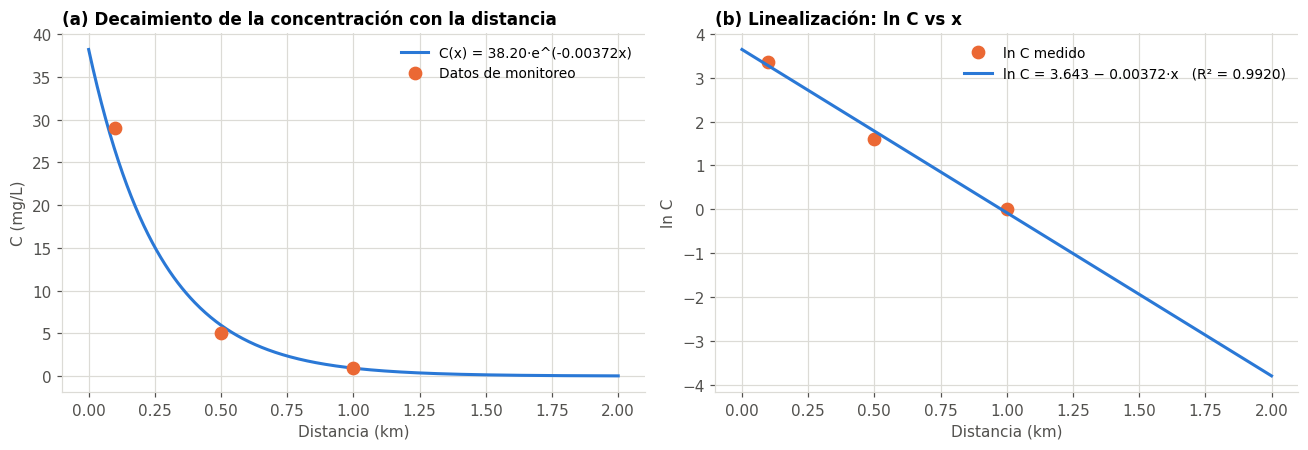

In [8]:
# ===== 4. GRÁFICAS =====
xg = np.linspace(0, 2000, 500)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(xg/1000, C_pred(xg), color=COL[0], label=f"C(x) = {C0:.2f}·e^(-{beta:.5f}x)")
ax[0].plot(x_km, C_m, "o", color=COL[1], ms=8, label="Datos de monitoreo")
ax[0].set_xlabel("Distancia (km)"); ax[0].set_ylabel("C (mg/L)"); ax[0].legend(fontsize=9)
ax[0].set_title("(a) Decaimiento de la concentración con la distancia")

ax[1].plot(x_m/1000, lnC, "o", color=COL[1], ms=8, label="ln C medido")
ax[1].plot(xg/1000, a_int + b_pend*xg, color=COL[0], label=f"ln C = {a_int:.3f} − {beta:.5f}·x   (R² = {R2:.4f})")
ax[1].set_xlabel("Distancia (km)"); ax[1].set_ylabel("ln C"); ax[1].legend(fontsize=9)
ax[1].set_title("(b) Linealización: ln C vs x")
fig.tight_layout(); fig.savefig(OUT/"ej2.png"); plt.show()

## 5. Análisis

**Modelo obtenido.** Los datos se ajustan muy bien a un decaimiento exponencial (**R² = 0.992**):
C(x) = 38.20 · e^(−0.00372·x), con x en metros. La concentración en el punto de descarga (x = 0) sería
**C₀ ≈ 38.20 mg/L** y la constante de decaimiento espacial es β = k/u = 0.00372 m⁻¹.

**Interpretación de la constante.** Como la velocidad del río es 1 m/s, la distancia se traduce
directamente en tiempo de viaje (t = x/u): k = β·u = **0.00372 s⁻¹ ≈ 321 día⁻¹**, es decir, una vida
media de **186 s ≈ 3.1 minutos**, o una **distancia de semirreducción de 186 m**: cada 186 m de recorrido
la concentración cae a la mitad.

**Por qué disminuye con la distancia.** La descarga es constante, así que no hay un pulso que se
ensanche: lo que ocurre es que el contaminante, mientras es arrastrado por la **advección**, se va
**degradando** (reacciones químicas y biológicas) siguiendo una cinética de primer orden. Como el tiempo
de exposición a esa degradación crece con la distancia recorrida, la concentración cae exponencialmente:
29 mg/L a 100 m, 5 mg/L a 500 m y 1 mg/L a 1 km, o sea una reducción del **96.6 % en el primer kilómetro**.

**Uso para el monitoreo y la mitigación.** El modelo permite estimar la concentración en cualquier punto
sin medir: por ejemplo, ≈ 15.1 mg/L a 250 m, ≈ 2.3 mg/L a 750 m y ≈ 0.02 mg/L a 2 km. Las estaciones de monitoreo deben
concentrarse en el primer kilómetro, que es donde ocurre casi toda la variación; más allá de 2 km el
contaminante es prácticamente indetectable. Para reducir el impacto, la medida efectiva es bajar la
carga en la fuente (C₀), porque el perfil completo es proporcional a ella.

---
# EJERCICIO 3 — Difusión de un compuesto químico en una capa de suelo (2.ª ley de Fick)

**Datos:** capa de suelo de 4 m · C₀ = 9 mol/m³ en el depósito superficial · a x = 0.8 m se mide
C = 4 mol/m³ · D = 8×10⁻¹⁰ m²/s

## 1. Modelo
Como la concentración cambia con el tiempo **y** con la posición, se usa la **segunda ley de Fick**:

$$\frac{\partial C}{\partial t} = D\,\frac{\partial^2 C}{\partial x^2}$$

Condiciones: superficie con concentración constante C(0,t) = C₀ = 9 mol/m³; suelo inicialmente limpio
C(x,0) = 0; capa suficientemente profunda (medio semi-infinito) C(∞,t) → 0. La solución analítica es:

$$C(x,t) = C_0\,\operatorname{erfc}\!\left(\frac{x}{2\sqrt{Dt}}\right)$$

Esta ecuación responde cómo cambia la distribución con el tiempo y la posición: la concentración decae
desde la superficie según la función error complementaria y el frente avanza proporcional a √(Dt).

In [9]:
# ===== DATOS =====
C0_3, x_med, C_med, D3, L3 = 9.0, 0.8, 4.0, 8e-10, 4.0     # mol/m³, m, mol/m³, m²/s, m

# ===== 2. TIEMPO TRANSCURRIDO A PARTIR DE LA MEDICIÓN =====
frac = C_med/C0_3
eta  = erfcinv(frac)                       # erfc(eta) = C/C0
raizDt = x_med/(2*eta)
t3   = raizDt**2/D3

display(Markdown("**2. Determinación del tiempo con el dato medido**"))
eq(rf"\frac{{C}}{{C_0}} = \frac{{{C_med:g}}}{{{C0_3:g}}} = {frac:.4f} = \operatorname{{erfc}}(\eta)"
   rf"\quad\Rightarrow\quad \eta = {eta:.4f}")
eq(rf"\eta = \frac{{x}}{{2\sqrt{{Dt}}}}\;\Rightarrow\;\sqrt{{Dt}} = \frac{{{x_med:g}}}{{2({eta:.4f})}} = {raizDt:.4f}\ \text{{m}}")
eq(rf"t = \frac{{({raizDt:.4f})^2}}{{{D3:g}}} = {t3:.3e}\ \text{{s}} = {t3/(365.25*86400):.1f}\ \text{{años}}")

**2. Determinación del tiempo con el dato medido**

$$\frac{C}{C_0} = \frac{4}{9} = 0.4444 = \operatorname{erfc}(\eta)\quad\Rightarrow\quad \eta = 0.5407$$

$$\eta = \frac{x}{2\sqrt{Dt}}\;\Rightarrow\;\sqrt{Dt} = \frac{0.8}{2(0.5407)} = 0.7397\ \text{m}$$

$$t = \frac{(0.7397)^2}{8e-10} = 6.840e+08\ \text{s} = 21.7\ \text{años}$$

## 3. Concentración en diferentes puntos de la capa

In [10]:
C_3 = lambda x, tt: C0_3*erfc(x/(2*np.sqrt(D3*tt)))
xs = np.array([0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 4.0])
tab3 = pd.DataFrame({"x (m)": xs, "x/(2·sqrt(D·t))": xs/(2*raizDt), "C (mol/m³)": C_3(xs, t3)})
tab3["% de C0"] = 100*tab3["C (mol/m³)"]/C0_3
display(tab3)
print(f"Verificación en el punto medido: C(0.8 m) = {C_3(0.8, t3):.2f} mol/m³ (dato: {C_med:g} mol/m³)")
print(f"A 4 m la concentración es {C_3(4.0, t3):.2e} mol/m³ -> se confirma la hipótesis de medio semi-infinito.")

,x (m),x/(2·sqrt(D·t)),C (mol/m³),% de C0
0,0.0,0.000000,9.000000,100.000000
1,0.4,0.270366,6.319784,70.219818
2,0.8,0.540731,4.000000,44.444444
3,1.2,0.811097,2.262195,25.135496
4,1.6,1.081463,1.135445,12.616052
5,2.0,1.351828,0.503146,5.590516
6,2.4,1.622194,0.196048,2.178309
7,2.8,1.892560,0.066959,0.743991
8,3.2,2.162926,0.019998,0.222197
9,4.0,2.703657,0.001184,0.013154


Verificación en el punto medido: C(0.8 m) = 4.00 mol/m³ (dato: 4 mol/m³)
A 4 m la concentración es 1.18e-03 mol/m³ -> se confirma la hipótesis de medio semi-infinito.


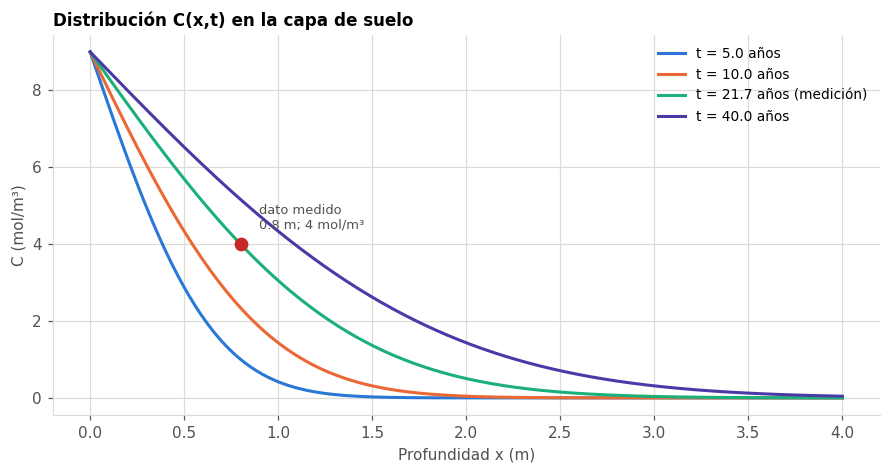

Profundidad de penetración (donde C = 1 % de C0) para cada tiempo:
  t =   5.0 años -> x = 1.29 m
  t =  10.0 años -> x = 1.83 m
  t =  21.7 años -> x = 2.69 m
  t =  40.0 años -> x = 3.66 m


In [11]:
# ===== 4. EVOLUCIÓN DEL PERFIL EN EL TIEMPO =====
anios = [5, 10, t3/(365.25*86400), 40]
xg = np.linspace(0, L3, 400)
fig, ax = plt.subplots()
for i, a_ in enumerate(anios):
    tt = a_*365.25*86400
    etiqueta = f"t = {a_:.1f} años" + (" (medición)" if abs(a_ - t3/(365.25*86400)) < 1e-6 else "")
    ax.plot(xg, C_3(xg, tt), color=COL[i], label=etiqueta)
ax.plot([x_med], [C_med], "o", color="#c62828", ms=8, zorder=5)
ax.annotate("dato medido\n0.8 m; 4 mol/m³", (x_med, C_med), xytext=(12, 10),
            textcoords="offset points", fontsize=8.5, color="#52514e")
ax.set_xlabel("Profundidad x (m)"); ax.set_ylabel("C (mol/m³)")
ax.set_title("Distribución C(x,t) en la capa de suelo"); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"ej3.png"); plt.show()

print("Profundidad de penetración (donde C = 1 % de C0) para cada tiempo:")
for a_ in anios:
    tt = a_*365.25*86400
    print(f"  t = {a_:5.1f} años -> x = {2*erfcinv(0.01)*np.sqrt(D3*tt):.2f} m")

## 5. Análisis

**Cómo cambia la distribución.** El perfil obedece C(x,t) = 9·erfc(x/(2√(Dt))): la concentración vale
siempre 9 mol/m³ en la superficie y decae hacia el interior de la capa. Con el dato medido (4 mol/m³ a
0.8 m) se determinó que han transcurrido **t ≈ 6.84×10⁸ s ≈ 21.7 años**, y con ese tiempo el perfil queda
completamente definido: 6.32 mol/m³ a 0.4 m, 4.00 mol/m³ a 0.8 m (coincide con la medición), 2.26 mol/m³
a 1.2 m, 0.50 mol/m³ a 2 m y prácticamente 0 a 4 m, lo que confirma que tratar la capa como **medio
semi-infinito** era válido.

**Comportamiento en el tiempo.** Todos los perfiles parten del mismo valor en la superficie y avanzan
hacia el interior, pero **cada vez más lento**, porque la profundidad de penetración crece solo con √(Dt):
para llegar al doble de profundidad se necesita **cuatro veces más tiempo**. Esto se debe a que la
difusión es un transporte lento, impulsado únicamente por el gradiente de concentración, sin ningún flujo
que arrastre el compuesto: el coeficiente D = 8×10⁻¹⁰ m²/s es muy pequeño, propio de un sólido o un suelo
compacto, y por eso el proceso se mide en años y no en horas.

> **Nota sobre el enunciado:** menciona que se midió en "dos puntos diferentes", pero solo aparece el dato
> de x = 0.8 m con 4 mol/m³, que es suficiente para determinar el tiempo. Si hubiera un segundo punto,
> serviría para verificar el valor de D o de t.

---
# EJERCICIO 4 — Tratamiento enzimático de un pesticida (Michaelis–Menten)

**Datos:** S₀ = 50 mg/L · S objetivo = 5 mg/L · V_max = 10 mg/(L·día) · K_M = 20 mg/L

## 1. Modelo
La degradación enzimática sigue la cinética de Michaelis–Menten:

$$-\frac{dS}{dt} = \frac{V_{max}\,S}{K_M + S}$$

Como S pasa de 50 a 5 mg/L, valores comparables a K_M = 20 mg/L, **no puede simplificarse** a orden cero
ni a primer orden: hay que integrar la ecuación completa.

## 2. Ecuación integrada
$$\int_{S_0}^{S}\frac{K_M + S}{S}\,dS = -V_{max}\int_0^t dt \qquad\Rightarrow\qquad
K_M\ln\frac{S_0}{S} + (S_0 - S) = V_{max}\,t$$

In [12]:
# ===== DATOS =====
S0, S_obj, Vmax, KM = 50.0, 5.0, 10.0, 20.0     # mg/L, mg/L, mg/(L·día), mg/L

# ===== 3. SUSTITUCIÓN =====
term_log = KM*np.log(S0/S_obj)
term_lin = S0 - S_obj
t4 = (term_log + term_lin)/Vmax

display(Markdown("**3. Sustitución de datos**"))
eq(rf"t = \frac{{K_M\ln(S_0/S) + (S_0-S)}}{{V_{{max}}}}"
   rf" = \frac{{{KM:g}\,\ln({S0:g}/{S_obj:g}) + ({S0:g}-{S_obj:g})}}{{{Vmax:g}}}")
eq(rf"t = \frac{{{KM:g}({np.log(S0/S_obj):.4f}) + {term_lin:g}}}{{{Vmax:g}}}"
   rf" = \frac{{{term_log:.2f} + {term_lin:g}}}{{{Vmax:g}}}")
eq(rf"\boxed{{t \approx {t4:.1f}\ \text{{días}}}}")

print(f"Aporte de la fase saturada  (S0-S)/Vmax      = {term_lin/Vmax:.2f} días")
print(f"Aporte de la fase final     KM·ln(S0/S)/Vmax = {term_log/Vmax:.2f} días")
print(f"Velocidad inicial  v(S0) = Vmax·S0/(KM+S0) = {Vmax*S0/(KM+S0):.2f} mg/(L·día)")
print(f"Velocidad final    v(S)  = Vmax·S/(KM+S)   = {Vmax*S_obj/(KM+S_obj):.2f} mg/(L·día)")

**3. Sustitución de datos**

$$t = \frac{K_M\ln(S_0/S) + (S_0-S)}{V_{max}} = \frac{20\,\ln(50/5) + (50-5)}{10}$$

$$t = \frac{20(2.3026) + 45}{10} = \frac{46.05 + 45}{10}$$

$$\boxed{t \approx 9.1\ \text{días}}$$

Aporte de la fase saturada  (S0-S)/Vmax      = 4.50 días
Aporte de la fase final     KM·ln(S0/S)/Vmax = 4.61 días
Velocidad inicial  v(S0) = Vmax·S0/(KM+S0) = 7.14 mg/(L·día)
Velocidad final    v(S)  = Vmax·S/(KM+S)   = 2.00 mg/(L·día)


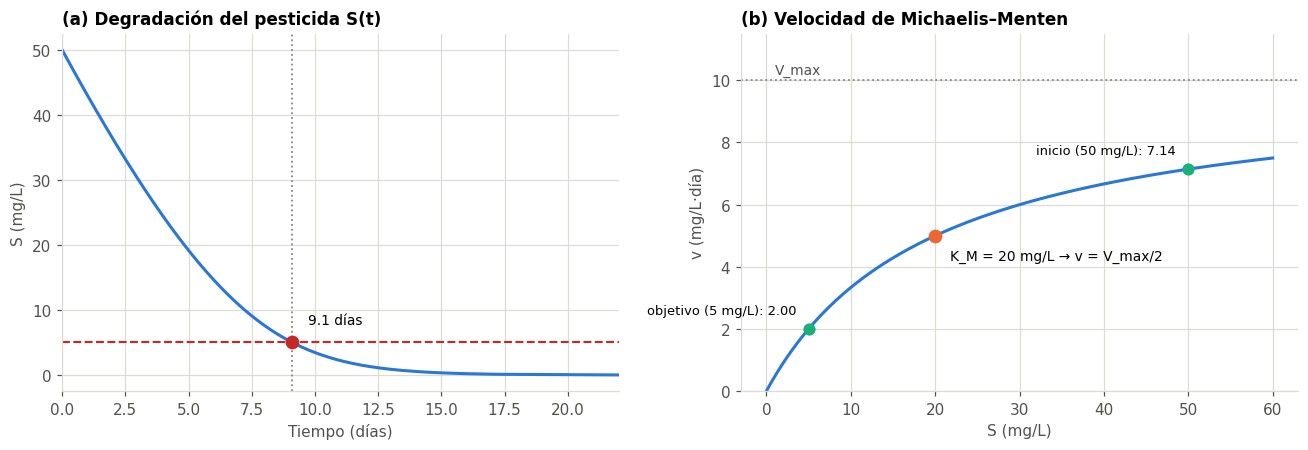

In [13]:
# ===== 4. CURVAS =====
S_grid = np.linspace(0.01, S0, 500)
t_de_S = (KM*np.log(S0/S_grid) + (S0 - S_grid))/Vmax      # tiempo para llegar a cada S

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(t_de_S, S_grid, color=COL[0])
ax[0].axhline(S_obj, color="#c62828", ls="--", lw=1.4)
ax[0].axvline(t4, color="#8a8981", ls=":", lw=1.2)
ax[0].plot([t4], [S_obj], "o", color="#c62828", ms=8)
ax[0].annotate(f"{t4:.1f} días", (t4, S_obj), xytext=(10, 12), textcoords="offset points", fontsize=9)
ax[0].set_xlim(0, t_de_S.max()); ax[0].set_xlabel("Tiempo (días)"); ax[0].set_ylabel("S (mg/L)")
ax[0].set_title("(a) Degradación del pesticida S(t)")

Sg = np.linspace(0, 60, 300)
ax[1].plot(Sg, Vmax*Sg/(KM + Sg), color=COL[0])
ax[1].axhline(Vmax, color="#8a8981", ls=":", lw=1.2); ax[1].text(1, Vmax*1.02, "V_max", fontsize=9, color="#52514e")
ax[1].plot([KM], [Vmax/2], "o", color=COL[1], ms=8)
ax[1].annotate(f"K_M = {KM:g} mg/L → v = V_max/2", (KM, Vmax/2), xytext=(10, -16),
               textcoords="offset points", fontsize=9)
for S_, etiqueta in [(S0, "inicio (50 mg/L)"), (S_obj, "objetivo (5 mg/L)")]:
    v_ = Vmax*S_/(KM + S_)
    ax[1].plot([S_], [v_], "o", color=COL[2], ms=7)
    ax[1].annotate(f"{etiqueta}: {v_:.2f}", (S_, v_), xytext=(-8, 10), textcoords="offset points",
                   fontsize=8.5, ha="right")
ax[1].set_xlabel("S (mg/L)"); ax[1].set_ylabel("v (mg/L·día)"); ax[1].set_ylim(0, Vmax*1.15)
ax[1].set_title("(b) Velocidad de Michaelis–Menten")
fig.tight_layout(); fig.savefig(OUT/"ej4.png"); plt.show()

## 5. Interpretación

Se necesitan aproximadamente **9.1 días** de tratamiento enzimático para bajar de 50 a 5 mg/L. El
resultado tiene dos contribuciones físicas:

- El término **(S₀ − S)/V_max = 4.5 días** representa la fase inicial, donde S ≫ K_M y la enzima trabaja
  casi saturada (velocidad cercana a V_max, comportamiento de **orden cero**).
- El término **K_M·ln(S₀/S)/V_max = 4.6 días** refleja la fase final, donde S se vuelve comparable o menor
  que K_M y la degradación se hace cada vez más lenta (comportamiento de **primer orden**).

Por eso, aunque los primeros 45 mg/L se eliminan relativamente rápido (la velocidad pasa de 7.14 a
2.00 mg/(L·día)), **la etapa final hacia los 5 mg/L consume casi la mitad del tiempo total**. Si se
quisiera acelerar el tratamiento habría que aumentar V_max (más dosis de enzima) o emplear una enzima con
menor K_M, que mantiene la velocidad alta a bajas concentraciones.